In [38]:
import numpy as np
import pandas as pd
import re
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import root_mean_squared_error, r2_score
from sklearn.model_selection import (train_test_split,GridSearchCV,RandomizedSearchCV,cross_val_score,
)
import tensorflow as tf
from sklearn.metrics import mean_squared_error as mse_score
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from pathlib import Path
import warnings
data=Path.cwd().parent.joinpath('Dataset')
tmdb_df=pd.read_csv('tmdb_movies_patricia.csv')

In [39]:
tmdb_df = tmdb_df.drop(columns=["genre_type","revenue_categories","num_genres"])

In [40]:

y_numpy=tmdb_df['revenue'].to_numpy()

In [41]:
tmdb_df = tmdb_df[tmdb_df["revenue"] > 0]

In [42]:
zero_count = (tmdb_df["budget"] == 0).sum()
zero_percent = (tmdb_df["budget"] == 0).mean() * 100

print("Zero budget count:", zero_count)
print("Zero budget %:", zero_percent)

Zero budget count: 147
Zero budget %: 4.354265402843602


In [43]:
zero_count = (tmdb_df["revenue"] == 0).sum()
zero_percent = (tmdb_df["revenue"] == 0).mean() * 100

print("Zero budget count:", zero_count)
print("Zero budget %:", zero_percent)


Zero budget count: 0
Zero budget %: 0.0


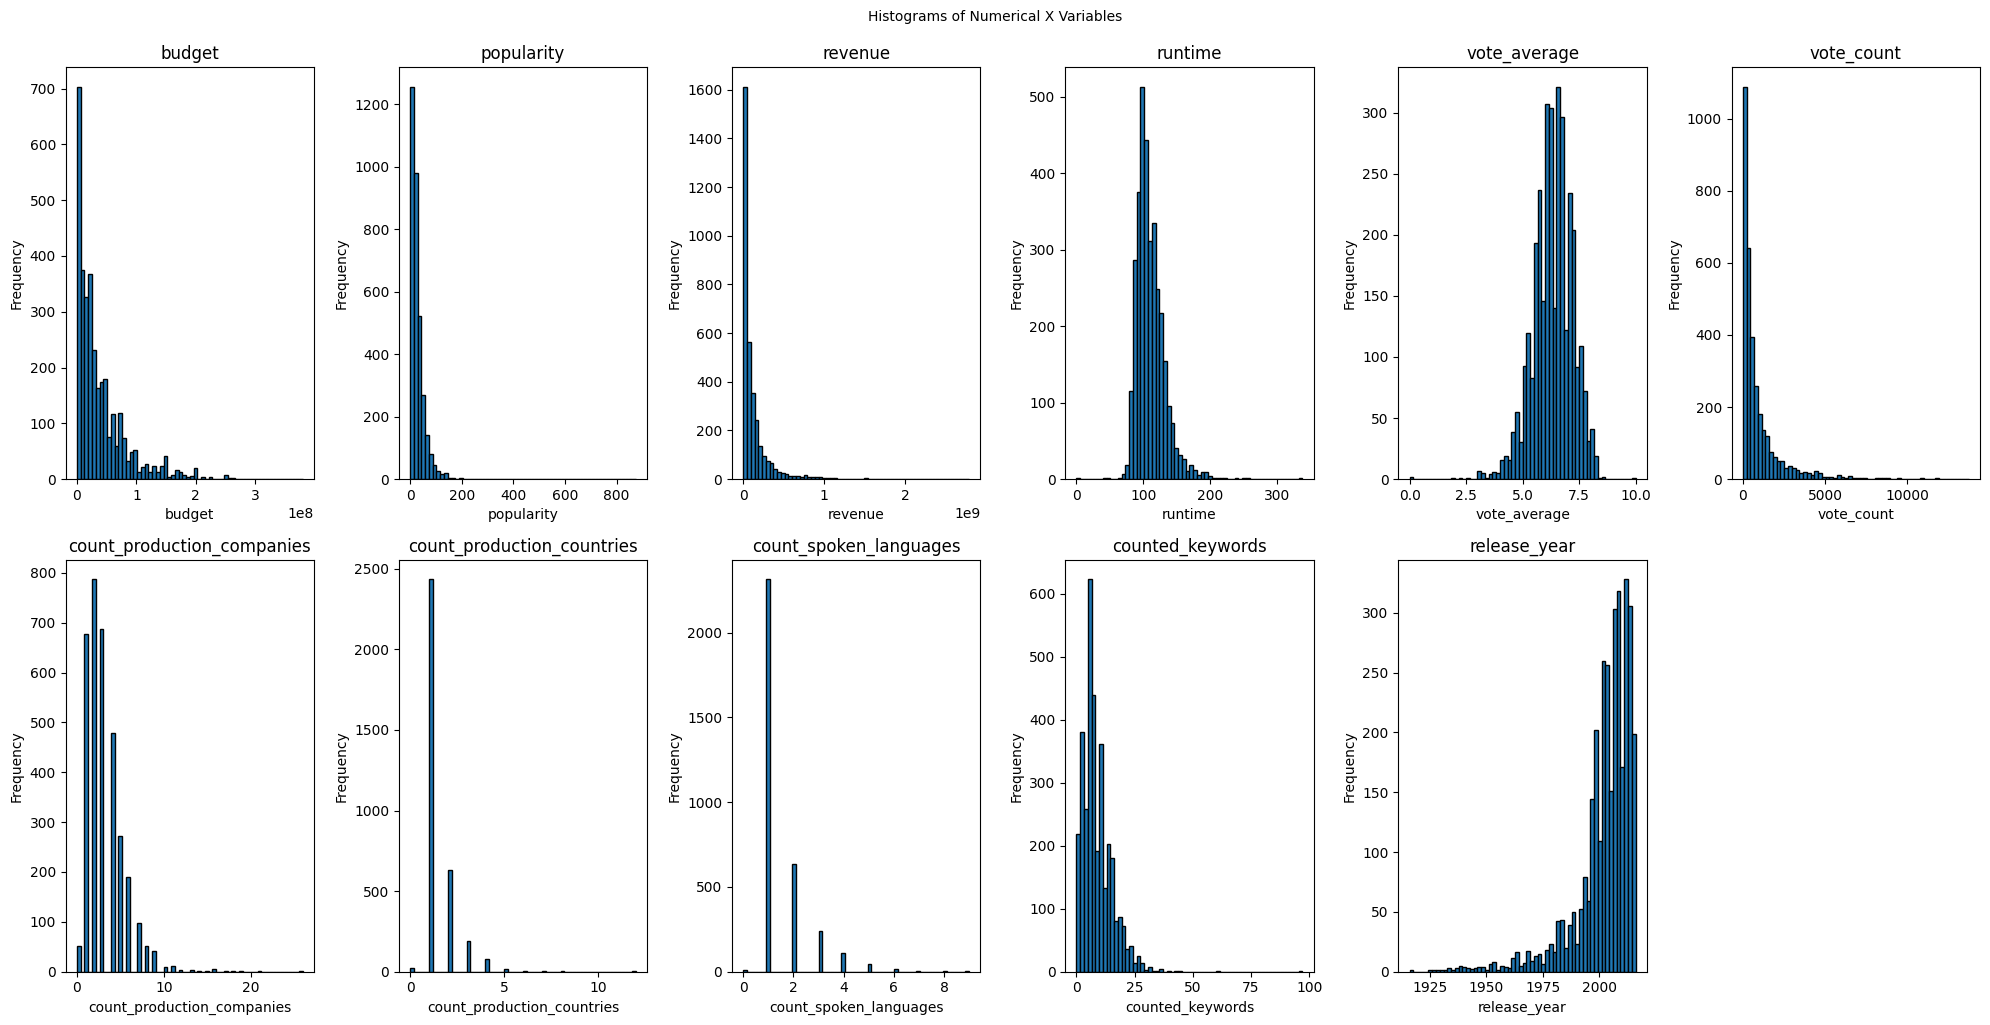

In [44]:
numerical_columns = tmdb_df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(20, 10))

for i, col in enumerate(numerical_columns.columns, 1):
    plt.subplot(2, (len(numerical_columns.columns) + 1) // 2, i)
    plt.hist(tmdb_df[col], bins=60, edgecolor='black')
    plt.title(f'{col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.suptitle('Histograms of Numerical X Variables', fontsize=10, y=1.02)
plt.show()

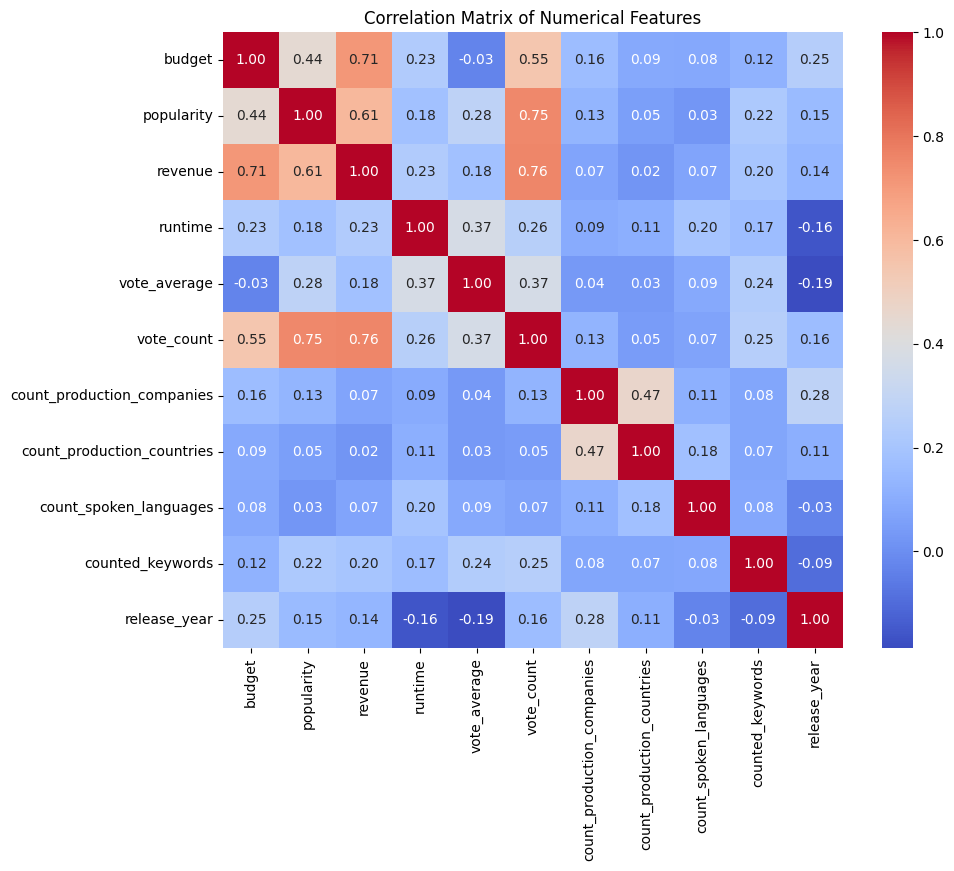

In [45]:
plt.figure(figsize=(10, 8))

corr = numerical_columns.corr()

sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix of Numerical Features")
plt.show()

In [46]:
tmdb_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3376 entries, 0 to 4798
Data columns (total 15 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   budget                      3376 non-null   int64  
 1   original_language           3376 non-null   object 
 2   popularity                  3376 non-null   float64
 3   release_date                3376 non-null   object 
 4   revenue                     3376 non-null   int64  
 5   runtime                     3376 non-null   float64
 6   status                      3376 non-null   object 
 7   vote_average                3376 non-null   float64
 8   vote_count                  3376 non-null   int64  
 9   count_production_companies  3376 non-null   int64  
 10  count_production_countries  3376 non-null   int64  
 11  count_spoken_languages      3376 non-null   int64  
 12  genres_clean                3375 non-null   object 
 13  counted_keywords            3376 non-n

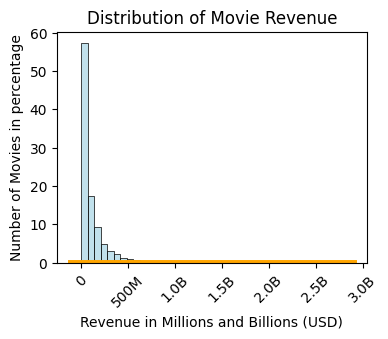

In [47]:

def format_currency(x, pos):
    if x >= 1e9:
        return f'{x/1e9:.1f}B'
    elif x >= 1e6:
        return f'{x/1e6:.0f}M'
    else:
        return f'{x:.0f}'

plt.figure(figsize=(4,3))
sns.histplot(tmdb_df["revenue"], bins=40, color="lightblue",stat="percent" )
sns.kdeplot(tmdb_df["revenue"], color="ORANGE", linewidth=5)

plt.title("Distribution of Movie Revenue")
plt.xlabel("Revenue in Millions and Billions (USD)")
plt.ylabel("Number of Movies in percentage")

plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(format_currency))
plt.xticks(rotation=45)

plt.show()



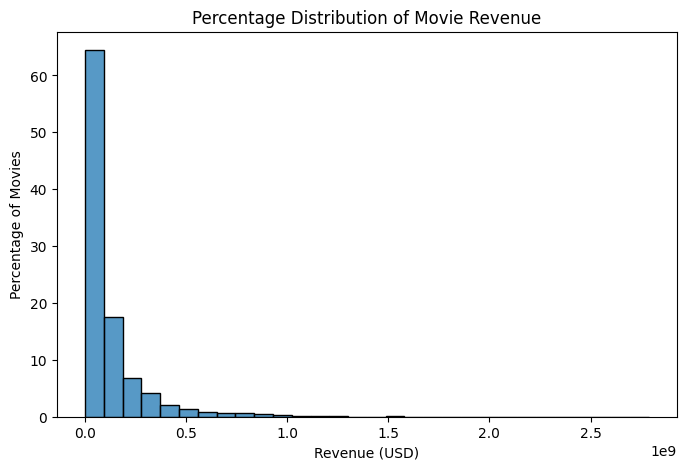

In [48]:
plt.figure(figsize=(8,5))

sns.histplot(
    tmdb_df["revenue"],
    bins=30,
    stat="percent" 
)

plt.title("Percentage Distribution of Movie Revenue")
plt.xlabel("Revenue (USD)")
plt.ylabel("Percentage of Movies")

plt.show()

In [49]:

tmdb_df["Revenue Range"] = pd.cut(tmdb_df["revenue"],bins=[0, 50e6, 100e6, 500e6, 1e9, tmdb_df["revenue"].max()],labels=["0-50M", "50M-100M", "100M-500M", "500M-1B", "1B+"]
)
percentage_table = (tmdb_df["Revenue Range"].value_counts(normalize=True) * 100).reset_index()

percentage_table.columns = ["Revenue Range", "Percentage"]
order = ["0-50M", "50M-100M", "100M-500M", "500M-1B", "1B+"]

percentage_table = (percentage_table.set_index("Revenue Range").loc[order].reset_index())

percentage_table


,Revenue Range,Percentage
0,0-50M,49.140995
1,50M-100M,17.505924
2,100M-500M,29.028436
3,500M-1B,3.702607
4,1B+,0.622038


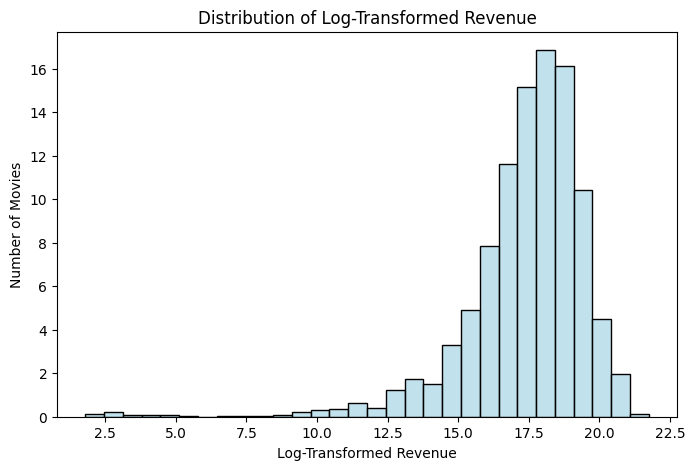

In [50]:
tmdb_df["log_revenue"] = np.log1p(tmdb_df["revenue"])

plt.figure(figsize=(8,5))
sns.histplot(tmdb_df["log_revenue"], bins=30, color="lightblue", stat="percent")

plt.title("Distribution of Log-Transformed Revenue")
plt.xlabel("Log-Transformed Revenue")
plt.ylabel("Number of Movies")

plt.show()

In [51]:
tmdb_df

,budget,original_language,popularity,release_date,revenue,runtime,status,vote_average,vote_count,count_production_companies,count_production_countries,count_spoken_languages,genres_clean,counted_keywords,release_year,Revenue Range,log_revenue
0,237000000,en,150.437577,2009-12-10,2787965087,162.0,Released,7.2,11800,4,2,2,"Action, Adventure, Fantasy, Science Fiction",21,2009.0,1B+,21.748578
1,300000000,en,139.082615,2007-05-19,961000000,169.0,Released,6.9,4500,3,1,1,"Adventure, Fantasy, Action",16,2007.0,500M-1B,20.683485
2,245000000,en,107.376788,2015-10-26,880674609,148.0,Released,6.3,4466,3,2,5,"Action, Adventure, Crime",7,2015.0,500M-1B,20.596199
3,250000000,en,112.312950,2012-07-16,1084939099,165.0,Released,7.6,9106,4,1,1,"Action, Crime, Drama, Thriller",21,2012.0,1B+,20.804790
4,260000000,en,43.926995,2012-03-07,284139100,132.0,Released,6.1,2124,1,1,1,"Action, Adventure, Science Fiction",16,2012.0,100M-500M,19.464974
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4775,0,en,0.362633,2002-09-20,76901,85.0,Released,6.3,8,0,1,1,"Drama, Comedy",1,2002.0,0-50M,11.250287
4788,12000,en,4.553644,1972-03-12,6000000,93.0,Released,6.2,110,1,1,1,"Horror, Comedy, Crime",17,1972.0,0-50M,15.607270
4792,20000,ja,0.212443,1997-11-06,99000,111.0,Released,7.4,63,1,1,1,"Crime, Horror, Mystery, Thriller",17,1997.0,0-50M,11.502885
4796,7000,en,23.307949,2004-10-08,424760,77.0,Released,6.9,658,1,1,1,"Science Fiction, Drama, Thriller",9,2004.0,0-50M,12.959282


In [52]:
tmdb_df["release_date"] = pd.to_datetime(tmdb_df["release_date"], errors="coerce")
tmdb_df["release_month"] = tmdb_df["release_date"].dt.month

In [53]:
X = tmdb_df.drop(columns=["revenue",'Revenue Range','log_revenue']).copy()
y = tmdb_df["revenue"].copy()


In [54]:

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.20, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42
)

print("Train size:", X_train.shape)
print("Validation size:", X_val.shape)
print("Test size:", X_test.shape)

Train size: (2700, 15)
Validation size: (338, 15)
Test size: (338, 15)


In [55]:


vectorizer = CountVectorizer()

genres_text = X_train["genres_clean"].fillna("").astype(str)

X_train_genres = vectorizer.fit_transform(genres_text)

X_df_train = pd.DataFrame(
    X_train_genres.toarray(),
    columns=vectorizer.get_feature_names_out(),
    index=X_train.index
)

X_df_train.head()

,action,adventure,animation,comedy,crime,documentary,drama,family,fantasy,fiction,foreign,history,horror,music,mystery,romance,science,thriller,war,western
3206,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0
826,0,0,0,0,1,0,1,0,0,0,0,0,0,0,1,1,0,1,0,0
3966,1,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0
1317,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0
2854,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0


In [56]:
def cyclic_transform(X, period):
    X = np.asarray(X).astype(float)
    sin_part = np.sin(2 * np.pi * X / period)
    cos_part = np.cos(2 * np.pi * X / period)
    return np.hstack([sin_part, cos_part])

In [57]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.preprocessing import FunctionTransformer, StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import Ridge
import numpy as np

numerical_columns = ["budget","popularity","runtime","vote_average","vote_count","count_production_companies","count_production_countries","count_spoken_languages","counted_keywords"]
categorical_data = ["status", "original_language"]
X_df_train = ['genres_clean']  

month_cyclic_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("cyclic", FunctionTransformer(cyclic_transform, kw_args={"period": 12}, validate=False)),
    ("scale", StandardScaler())
])

text_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="constant", fill_value="")),
    ("flatten", FunctionTransformer(lambda x: x.ravel(), validate=False, feature_names_out="one-to-one")),
    ("vectorize", TfidfVectorizer())])

num_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("standardize", StandardScaler()),
])

cat_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False, drop="first"))
])

preprocessing = ColumnTransformer([
    ("num", num_pipeline, numerical_columns),
    ("cat", cat_pipeline, categorical_data),
     ("text", text_pipeline, ["genres_clean"]),
    ("month_cyclic", month_cyclic_pipeline, ["release_month"])
])
preprocessing

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e

In [58]:
tmdb_df

,budget,original_language,popularity,release_date,revenue,runtime,status,vote_average,vote_count,count_production_companies,count_production_countries,count_spoken_languages,genres_clean,counted_keywords,release_year,Revenue Range,log_revenue,release_month
0,237000000,en,150.437577,2009-12-10,2787965087,162.0,Released,7.2,11800,4,2,2,"Action, Adventure, Fantasy, Science Fiction",21,2009.0,1B+,21.748578,12
1,300000000,en,139.082615,2007-05-19,961000000,169.0,Released,6.9,4500,3,1,1,"Adventure, Fantasy, Action",16,2007.0,500M-1B,20.683485,5
2,245000000,en,107.376788,2015-10-26,880674609,148.0,Released,6.3,4466,3,2,5,"Action, Adventure, Crime",7,2015.0,500M-1B,20.596199,10
3,250000000,en,112.312950,2012-07-16,1084939099,165.0,Released,7.6,9106,4,1,1,"Action, Crime, Drama, Thriller",21,2012.0,1B+,20.804790,7
4,260000000,en,43.926995,2012-03-07,284139100,132.0,Released,6.1,2124,1,1,1,"Action, Adventure, Science Fiction",16,2012.0,100M-500M,19.464974,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4775,0,en,0.362633,2002-09-20,76901,85.0,Released,6.3,8,0,1,1,"Drama, Comedy",1,2002.0,0-50M,11.250287,9
4788,12000,en,4.553644,1972-03-12,6000000,93.0,Released,6.2,110,1,1,1,"Horror, Comedy, Crime",17,1972.0,0-50M,15.607270,3
4792,20000,ja,0.212443,1997-11-06,99000,111.0,Released,7.4,63,1,1,1,"Crime, Horror, Mystery, Thriller",17,1997.0,0-50M,11.502885,11
4796,7000,en,23.307949,2004-10-08,424760,77.0,Released,6.9,658,1,1,1,"Science Fiction, Drama, Thriller",9,2004.0,0-50M,12.959282,10


In [59]:
linear_reg_pipe = Pipeline([("preprocessing", preprocessing),("linear_reg", LinearRegression())])

linear_reg_pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('linear_reg', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different tran

In [60]:

ridge_reg = TransformedTargetRegressor(
    regressor=Ridge(),
    func=np.log1p,
    inverse_func=np.expm1
)

ridge_pipeline = Pipeline([('prep', preprocessing), ('ridge_reg', ridge_reg)])

cv_ridge = GridSearchCV(
    ridge_pipeline,
    param_grid={'ridge_reg__regressor__alpha': [0.01, 0.1, 1, 10]},
    scoring='neg_root_mean_squared_error',
    cv=5,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)
cv_ridge.fit(X_train, y_train)

print("16a: Hyperparameters")
print("Tried  - alpha:", [0.01, 0.1, 1, 10])
print("Best   -", cv_ridge.best_params_)


best_idx = cv_ridge.best_index_
cv_mean = -cv_ridge.cv_results_["mean_test_score"][best_idx]
cv_std = cv_ridge.cv_results_["std_test_score"][best_idx]
print("\n16c: CV Results (best params)")
print(f"CV Mean RMSE: {cv_mean:,.0f}")
print(f"CV Std RMSE:  {cv_std:,.0f}")


y_test_pred = cv_ridge.best_estimator_.predict(X_test)
test_rmse = root_mean_squared_error(y_test, y_test_pred)
print("\n16b: Test Set Results")
print(f"Test RMSE: {test_rmse:,.0f}")


Fitting 5 folds for each of 4 candidates, totalling 20 fits
16a: Hyperparameters
Tried  - alpha: [0.01, 0.1, 1, 10]
Best   - {'ridge_reg__regressor__alpha': 0.1}

16c: CV Results (best params)
CV Mean RMSE: 281,160,645,664
CV Std RMSE:  559,961,971,318

16b: Test Set Results
Test RMSE: 1,572,581,563


c:\Users\That black girl\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [0, 1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


In [61]:

dt_reg = TransformedTargetRegressor(
    regressor=DecisionTreeRegressor(random_state=42),
    func=np.log1p,
    inverse_func=np.expm1
)

dt_pipeline = Pipeline([('prep', preprocessing), ('dt_reg', dt_reg)])

cv_dt = GridSearchCV(
    dt_pipeline,
    param_grid={
        'dt_reg__regressor__max_depth': [3, 5, 10, 15, None],
        'dt_reg__regressor__min_samples_split': [2, 5, 10]
    },
    scoring='neg_root_mean_squared_error',
    cv=5,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)
cv_dt.fit(X_train, y_train)

print("16a: Hyperparameters")
print("Tried  - max_depth:", [3, 5, 10, 15, None])
print("Tried  - min_samples_split:", [2, 5, 10])
print("Best   -", cv_dt.best_params_)


best_idx = cv_dt.best_index_
cv_mean = -cv_dt.cv_results_["mean_test_score"][best_idx]
cv_std = cv_dt.cv_results_["std_test_score"][best_idx]
print("\n16c: CV Results (best params)")
print(f"CV Mean RMSE: {cv_mean:,.0f}")
print(f"CV Std RMSE:  {cv_std:,.0f}")


y_test_pred = cv_dt.best_estimator_.predict(X_test)
test_rmse = root_mean_squared_error(y_test, y_test_pred)
print("\n16b: Test Set Results")
print(f"Test RMSE: {test_rmse:,.0f}")

Fitting 5 folds for each of 15 candidates, totalling 75 fits
16a: Hyperparameters
Tried  - max_depth: [3, 5, 10, 15, None]
Tried  - min_samples_split: [2, 5, 10]
Best   - {'dt_reg__regressor__max_depth': 5, 'dt_reg__regressor__min_samples_split': 2}

16c: CV Results (best params)
CV Mean RMSE: 101,988,571
CV Std RMSE:  5,764,843

16b: Test Set Results
Test RMSE: 136,721,521


c:\Users\That black girl\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [0, 1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


In [62]:

svr_reg = TransformedTargetRegressor(
    regressor=SVR(),
    func=np.log1p,
    inverse_func=np.expm1
)

svr_pipeline = Pipeline([('prep', preprocessing), ('svr_reg', svr_reg)])

cv_svr = GridSearchCV(
    svr_pipeline,
    param_grid={
        'svr_reg__regressor__C': [0.1, 1, 10, 100],
        'svr_reg__regressor__kernel': ['rbf'],
        'svr_reg__regressor__gamma': ['scale', 'auto']
    },
    scoring='neg_root_mean_squared_error',
    cv=5,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)
cv_svr.fit(X_train, y_train)


print("16a: Hyperparameters")
print("Tried  - C:", [0.1, 1, 10, 100])
print("Tried  - kernel:", ['rbf'])
print("Tried  - gamma:", ['scale', 'auto'])
print("Best   -", cv_svr.best_params_)


best_idx = cv_svr.best_index_
cv_mean = -cv_svr.cv_results_["mean_test_score"][best_idx]
cv_std = cv_svr.cv_results_["std_test_score"][best_idx]
print("\n16c: CV Results (best params)")
print(f"CV Mean RMSE: {cv_mean:,.0f}")
print(f"CV Std RMSE:  {cv_std:,.0f}")


y_test_pred = cv_svr.best_estimator_.predict(X_test)
test_rmse = root_mean_squared_error(y_test, y_test_pred)
print("\n16b: Test Set Results")
print(f"Test RMSE: {test_rmse:,.0f}")

Fitting 5 folds for each of 8 candidates, totalling 40 fits
16a: Hyperparameters
Tried  - C: [0.1, 1, 10, 100]
Tried  - kernel: ['rbf']
Tried  - gamma: ['scale', 'auto']
Best   - {'svr_reg__regressor__C': 1, 'svr_reg__regressor__gamma': 'auto', 'svr_reg__regressor__kernel': 'rbf'}

16c: CV Results (best params)
CV Mean RMSE: 100,152,221
CV Std RMSE:  6,476,669

16b: Test Set Results
Test RMSE: 133,182,041


c:\Users\That black girl\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [0, 1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


In [63]:

rf_reg = TransformedTargetRegressor(
    regressor=RandomForestRegressor(random_state=42),
    func=np.log1p,
    inverse_func=np.expm1
)

rf_pipeline = Pipeline([('prep', preprocessing), ('rf_reg', rf_reg)])

cv_rf = GridSearchCV(
    rf_pipeline,
    param_grid={
        'rf_reg__regressor__n_estimators': [100, 200],
        'rf_reg__regressor__max_depth': [5, 10, None],
        'rf_reg__regressor__min_samples_split': [2, 5]
    },
    scoring='neg_root_mean_squared_error',
    cv=5,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)
cv_rf.fit(X_train, y_train)

print("16a: Hyperparameters")
print("Tried  - n_estimators:", [100, 200])
print("Tried  - max_depth:", [5, 10, None])
print("Tried  - min_samples_split:", [2, 5])
print("Best   -", cv_rf.best_params_)

best_idx = cv_rf.best_index_
cv_mean = -cv_rf.cv_results_["mean_test_score"][best_idx]
cv_std = cv_rf.cv_results_["std_test_score"][best_idx]
print("\n16c: CV Results (best params)")
print(f"CV Mean RMSE: {cv_mean:,.0f}")
print(f"CV Std RMSE:  {cv_std:,.0f}")

y_test_pred = cv_rf.best_estimator_.predict(X_test)
test_rmse = root_mean_squared_error(y_test, y_test_pred)
print("\n16b: Test Set Results")
print(f"Test RMSE: {test_rmse:,.0f}")


Fitting 5 folds for each of 12 candidates, totalling 60 fits
16a: Hyperparameters
Tried  - n_estimators: [100, 200]
Tried  - max_depth: [5, 10, None]
Tried  - min_samples_split: [2, 5]
Best   - {'rf_reg__regressor__max_depth': None, 'rf_reg__regressor__min_samples_split': 2, 'rf_reg__regressor__n_estimators': 200}

16c: CV Results (best params)
CV Mean RMSE: 86,422,343
CV Std RMSE:  3,827,795

16b: Test Set Results
Test RMSE: 114,037,280


c:\Users\That black girl\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [0, 1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


In [64]:

gradient_boosting_reg = TransformedTargetRegressor(
    regressor=GradientBoostingRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        n_iter_no_change=20,
        validation_fraction=0.1,
        random_state=42
    ),
    func=np.log1p,
    inverse_func=np.expm1
)

gradient_boosting_pipeline = Pipeline([
    ('prep', preprocessing),
    ('gradient_boosting_reg', gradient_boosting_reg)
])

gradient_boosting_pipeline.fit(X_train, y_train)


n_trees = gradient_boosting_pipeline.named_steps["gradient_boosting_reg"].regressor_.n_estimators_
print("16a: Hyperparameters")
print("Used   - learning_rate: 0.05, max_depth: 4, subsample: 0.8")
print("Used   - n_iter_no_change: 20 (early stopping)")
print(f"Result - stopped at {n_trees} trees (out of 500 max)")

y_gradient_boosting_val = gradient_boosting_pipeline.predict(X_val)
gradient_boosting_val_rmse = root_mean_squared_error(y_val, y_gradient_boosting_val)
print("\n16c: Validation Results (early stopping, no CV)")
print(f"Validation RMSE: {gradient_boosting_val_rmse:,.0f}")

y_gradient_boosting_test = gradient_boosting_pipeline.predict(X_test)
gradient_boosting_test_rmse = root_mean_squared_error(y_test, y_gradient_boosting_test)
print("\n16b: Test Set Results")
print(f"Test RMSE: {gradient_boosting_test_rmse:,.0f}")

16a: Hyperparameters
Used   - learning_rate: 0.05, max_depth: 4, subsample: 0.8
Used   - n_iter_no_change: 20 (early stopping)
Result - stopped at 102 trees (out of 500 max)

16c: Validation Results (early stopping, no CV)
Validation RMSE: 156,657,342

16b: Test Set Results
Test RMSE: 123,389,842


c:\Users\That black girl\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
c:\Users\That black girl\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [0, 1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


In [65]:

X_train_nn = preprocessing.fit_transform(X_train)
X_val_nn   = preprocessing.transform(X_val)
X_test_nn  = preprocessing.transform(X_test)


if hasattr(X_train_nn, 'toarray'):
    X_train_nn = X_train_nn.toarray()
    X_val_nn   = X_val_nn.toarray()
    X_test_nn  = X_test_nn.toarray()


y_train_log = np.log1p(y_train).values
y_val_log   = np.log1p(y_val).values
y_test_log  = np.log1p(y_test).values


def create_model(n_layers, n_neurons, activation,
                 use_dropout=False, optimizer="adam", input_shape=None):
    model = tf.keras.Sequential()
    model.add(tf.keras.layers.Input(shape=input_shape))
    for _ in range(n_layers):
        model.add(tf.keras.layers.Dense(n_neurons, activation=activation))
    if use_dropout:
        model.add(tf.keras.layers.Dropout(0.3))
    model.add(tf.keras.layers.Dense(1))
    model.compile(
        loss="mean_squared_error",
        optimizer=optimizer,
        metrics=[tf.keras.metrics.RootMeanSquaredError()]
    )
    return model

scenarios = {
    "scenario_01": {"n_layers": 1, "n_neurons": 10,  "activation": "relu", "use_dropout": False, "optimizer": "adam"},
    "scenario_02": {"n_layers": 1, "n_neurons": 10,  "activation": "tanh", "use_dropout": False, "optimizer": "adam"},
    "scenario_03": {"n_layers": 1, "n_neurons": 50,  "activation": "relu", "use_dropout": False, "optimizer": "adam"},
    "scenario_04": {"n_layers": 2, "n_neurons": 64,  "activation": "relu", "use_dropout": False, "optimizer": "adam"},
    "scenario_05": {"n_layers": 3, "n_neurons": 64,  "activation": "relu", "use_dropout": True,  "optimizer": "adam"},
}


print("16a: Configurations Tried")
for name, params in scenarios.items():
    print(f"  {name}: layers={params['n_layers']}, neurons={params['n_neurons']}, "
          f"activation={params['activation']}, dropout={params['use_dropout']}, optimizer={params['optimizer']}")

nn_results = {}
early_stopping_cb = tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)

for scenario_name, params in scenarios.items():
    model = create_model(
        n_layers=params["n_layers"],
        n_neurons=params["n_neurons"],
        activation=params["activation"],
        use_dropout=params["use_dropout"],
        optimizer=params["optimizer"],
        input_shape=(X_train_nn.shape[1],)
    )
    model.fit(
        X_train_nn, y_train_log,
        validation_data=(X_val_nn, y_val_log),
        epochs=100,
        callbacks=[early_stopping_cb],
        verbose=0
    )
    y_pred_log = model.predict(X_test_nn, verbose=0)
    y_pred = np.expm1(y_pred_log).ravel()
    y_true = np.expm1(y_test_log)

    test_mse  = mse_score(y_true, y_pred)
    test_rmse = np.sqrt(test_mse)
    nn_results[scenario_name] = {"mse": test_mse, "rmse": test_rmse}
    print(f"  {scenario_name}: Test MSE = {test_mse:,.2f} | Test RMSE = {test_rmse:,.2f}")


best_scenario = min(nn_results, key=lambda x: nn_results[x]["rmse"])
nn_test_rmse  = nn_results[best_scenario]["rmse"]
best_nn_config = f"{best_scenario} — {scenarios[best_scenario]}"

print("\n 16c: Validation Results (early stopping, no CV)")
print("All scenarios trained with EarlyStopping(patience=5, restore_best_weights=True)")
for name, res in nn_results.items():
    print(f"  {name}: Test RMSE = {res['rmse']:,.2f}")

print("\n16b: Test Set Results")
print(f"Best Scenario : {best_scenario}")
print(f"Configuration : {scenarios[best_scenario]}")
print(f"Test RMSE     : {nn_test_rmse:,.2f}")

16a: Configurations Tried
  scenario_01: layers=1, neurons=10, activation=relu, dropout=False, optimizer=adam
  scenario_02: layers=1, neurons=10, activation=tanh, dropout=False, optimizer=adam
  scenario_03: layers=1, neurons=50, activation=relu, dropout=False, optimizer=adam
  scenario_04: layers=2, neurons=64, activation=relu, dropout=False, optimizer=adam
  scenario_05: layers=3, neurons=64, activation=relu, dropout=True, optimizer=adam


c:\Users\That black girl\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
c:\Users\That black girl\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [0, 1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


  scenario_01: Test MSE = 14,814,255,735,666,440.00 | Test RMSE = 121,713,827.22
  scenario_02: Test MSE = 63,707,539,972,723,936.00 | Test RMSE = 252,403,526.07
  scenario_03: Test MSE = 63,707,470,667,870,024.00 | Test RMSE = 252,403,388.78
  scenario_04: Test MSE = 1,550,254,158,721,309,884,631,286,779,215,872.00 | Test RMSE = 39,373,267,056,739,272.00
  scenario_05: Test MSE = 492,211,048,761,024,683,967,705,513,984.00 | Test RMSE = 701,577,542,942,349.75

 16c: Validation Results (early stopping, no CV)
All scenarios trained with EarlyStopping(patience=5, restore_best_weights=True)
  scenario_01: Test RMSE = 121,713,827.22
  scenario_02: Test RMSE = 252,403,526.07
  scenario_03: Test RMSE = 252,403,388.78
  scenario_04: Test RMSE = 39,373,267,056,739,272.00
  scenario_05: Test RMSE = 701,577,542,942,349.75

16b: Test Set Results
Best Scenario : scenario_01
Configuration : {'n_layers': 1, 'n_neurons': 10, 'activation': 'relu', 'use_dropout': False, 'optimizer': 'adam'}
Test RMSE   

In [66]:
results = []

grid_models = {
    "Ridge Regression": cv_ridge,
    "Decision Tree": cv_dt,
    "SVR": cv_svr,
    "Random Forest": cv_rf,
}

for name, grid in grid_models.items():
    best_idx = grid.best_index_
    cv_mean = -grid.cv_results_["mean_test_score"][best_idx]
    cv_std = grid.cv_results_["std_test_score"][best_idx]
    y_pred = grid.best_estimator_.predict(X_test)
    test_rmse = root_mean_squared_error(y_test, y_pred)
    results.append({
        "Model": name,
        "Best Hyperparameters": str(grid.best_params_),
        "Mean CV RMSE": round(cv_mean, 2),
        "Standard Deviation": round(cv_std, 2),
        "Test RMSE": round(test_rmse, 2)
    })

y_gradient_boosting_pred = gradient_boosting_pipeline.predict(X_test)
gradient_boosting_rmse = root_mean_squared_error(y_test, y_gradient_boosting_pred)
results.append({
    "Model": "Gradient Boosting",
    "Best Hyperparameters": "Early Stopping (n_iter_no_change=20)",
    "Mean CV RMSE": "N/A",
    "Standard Deviation": "N/A",
    "Test RMSE": round(gradient_boosting_rmse, 2)
})

results.append({
    "Model": "Neural Network",
    "Best Hyperparameters": best_nn_config,
    "Mean CV RMSE": "N/A",
    "Standard Deviation": "N/A",
    "Test RMSE": round(nn_test_rmse, 2)
})

summary_df = pd.DataFrame(results)
summary_df.index = range(1, len(summary_df) + 1)
summary_df.index.name = None
pd.set_option('display.max_colwidth', None)
summary_df

c:\Users\That black girl\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [0, 1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
c:\Users\That black girl\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [0, 1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
c:\Users\That black girl\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [0, 1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
c:\Users\That black girl\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unk

,Model,Best Hyperparameters,Mean CV RMSE,Standard Deviation,Test RMSE
1,Ridge Regression,{'ridge_reg__regressor__alpha': 0.1},281160645664.099976,559961971318.310059,1.572582e+09
2,Decision Tree,"{'dt_reg__regressor__max_depth': 5, 'dt_reg__regressor__min_samples_split': 2}",101988571.05,5764843.18,1.367215e+08
3,SVR,"{'svr_reg__regressor__C': 1, 'svr_reg__regressor__gamma': 'auto', 'svr_reg__regressor__kernel': 'rbf'}",100152220.63,6476668.83,1.331820e+08
4,Random Forest,"{'rf_reg__regressor__max_depth': None, 'rf_reg__regressor__min_samples_split': 2, 'rf_reg__regressor__n_estimators': 200}",86422343.13,3827794.96,1.140373e+08
5,Gradient Boosting,Early Stopping (n_iter_no_change=20),N/A,N/A,1.233898e+08
6,Neural Network,"scenario_01 — {'n_layers': 1, 'n_neurons': 10, 'activation': 'relu', 'use_dropout': False, 'optimizer': 'adam'}",N/A,N/A,1.217138e+08


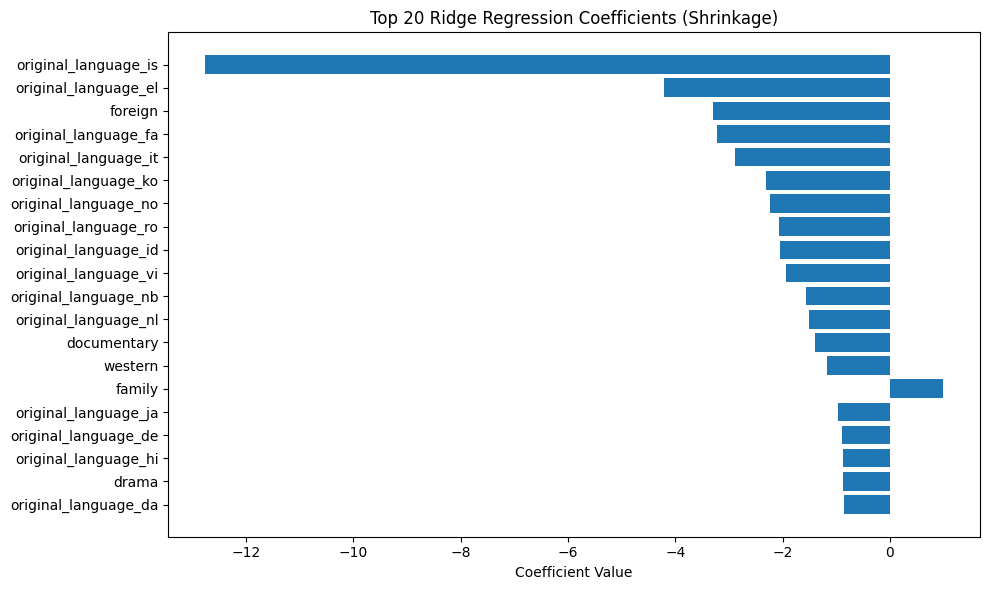

In [67]:

ridge_regressor = cv_ridge.best_estimator_.named_steps["ridge_reg"].regressor_
coefficients = ridge_regressor.coef_


prep = cv_ridge.best_estimator_.named_steps["prep"]
cat_names  = list(prep.named_transformers_["cat"].named_steps["onehot"].get_feature_names_out(categorical_data))
text_names = list(prep.named_transformers_["text"].named_steps["vectorize"].get_feature_names_out())
feature_names_ridge = numerical_columns + cat_names + text_names + ["month_sin", "month_cos"]

coef_df = pd.DataFrame({
    "Feature": feature_names_ridge,
    "Coefficient": coefficients
}).sort_values("Coefficient", key=abs, ascending=False).head(20)

plt.figure(figsize=(10, 6))
plt.barh(coef_df["Feature"][::-1], coef_df["Coefficient"][::-1])
plt.xlabel("Coefficient Value")
plt.title("Top 20 Ridge Regression Coefficients (Shrinkage)")
plt.tight_layout()
plt.show()

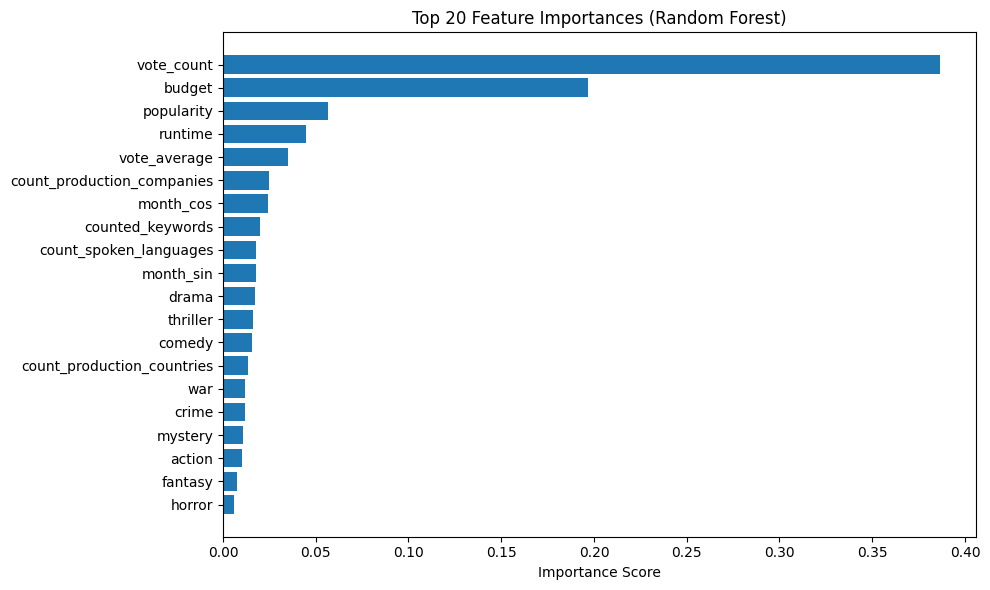

In [68]:

rf_regressor = cv_rf.best_estimator_.named_steps["rf_reg"].regressor_
importances = rf_regressor.feature_importances_

prep = cv_rf.best_estimator_.named_steps["prep"]
cat_names  = list(prep.named_transformers_["cat"].named_steps["onehot"].get_feature_names_out(categorical_data))
text_names = list(prep.named_transformers_["text"].named_steps["vectorize"].get_feature_names_out())
feature_names_rf = numerical_columns + cat_names + text_names + ["month_sin", "month_cos"]

feat_imp_df = pd.DataFrame({
    "Feature": feature_names_rf,
    "Importance": importances
}).sort_values("Importance", ascending=False).head(20)

plt.figure(figsize=(10, 6))
plt.barh(feat_imp_df["Feature"][::-1], feat_imp_df["Importance"][::-1])
plt.xlabel("Importance Score")
plt.title("Top 20 Feature Importances (Random Forest)")
plt.tight_layout()
plt.show()


Best to Worst by Test RMSE:
               Model     Test RMSE
1      Random Forest  1.140373e+08
2     Neural Network  1.217138e+08
3  Gradient Boosting  1.233898e+08
4                SVR  1.331820e+08
5      Decision Tree  1.367215e+08
6   Ridge Regression  1.572582e+09


c:\Users\That black girl\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [0, 1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
c:\Users\That black girl\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [0, 1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
c:\Users\That black girl\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [0, 1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
c:\Users\That black girl\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unk

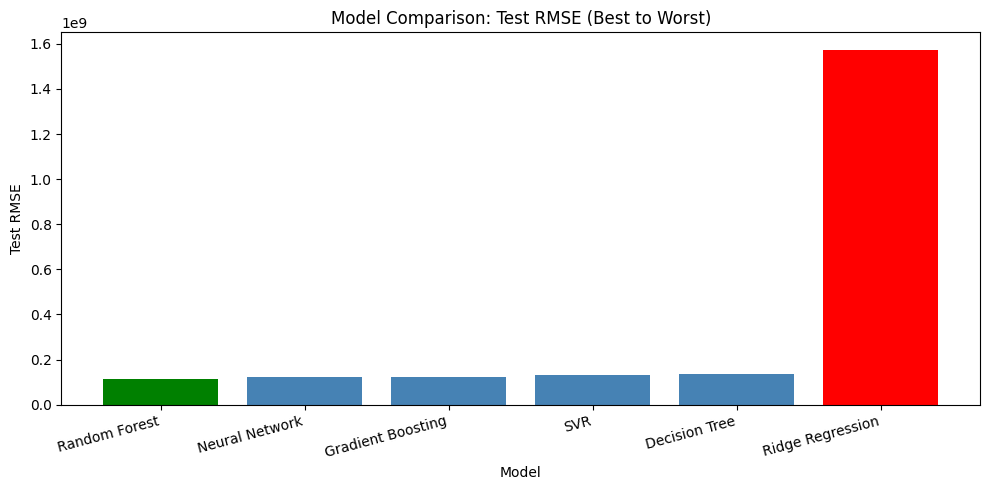

In [69]:

model_scores = {
    "Ridge Regression":   root_mean_squared_error(y_test, cv_ridge.best_estimator_.predict(X_test)),
    "Decision Tree":      root_mean_squared_error(y_test, cv_dt.best_estimator_.predict(X_test)),
    "SVR":                root_mean_squared_error(y_test, cv_svr.best_estimator_.predict(X_test)),
    "Random Forest":      root_mean_squared_error(y_test, cv_rf.best_estimator_.predict(X_test)),
    "Gradient Boosting":  root_mean_squared_error(y_test, gradient_boosting_pipeline.predict(X_test)),
    "Neural Network":     nn_test_rmse,
}

comparison_df = pd.DataFrame(
    model_scores.items(), columns=["Model", "Test RMSE"]
).sort_values("Test RMSE").reset_index(drop=True)
comparison_df.index = range(1, len(comparison_df) + 1)

print("Best to Worst by Test RMSE:")
print(comparison_df.to_string())

colors = ["green" if i == 0 else "red" if i == len(comparison_df) - 1 else "steelblue"
          for i in range(len(comparison_df))]

plt.figure(figsize=(10, 5))
plt.bar(comparison_df["Model"], comparison_df["Test RMSE"], color=colors)
plt.xlabel("Model")
plt.ylabel("Test RMSE")
plt.title("Model Comparison: Test RMSE (Best to Worst)")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

In [70]:
q17_data = []

grid_models_q17 = {
    "Ridge Regression": cv_ridge,
    "Decision Tree":    cv_dt,
    "SVR":              cv_svr,
    "Random Forest":    cv_rf,
}

for name, grid in grid_models_q17.items():
    best_idx  = grid.best_index_
    cv_mean   = -grid.cv_results_["mean_test_score"][best_idx]
    cv_std    =  grid.cv_results_["std_test_score"][best_idx]
    test_rmse =  root_mean_squared_error(y_test, grid.best_estimator_.predict(X_test))
    q17_data.append({"Model": name,
                     "Mean CV RMSE": round(cv_mean, 2),
                     "Std. Dev.": round(cv_std, 2),
                     "Test RMSE": round(test_rmse, 2)})

q17_data.append({"Model": "Gradient Boosting",
                 "Mean CV RMSE": "N/A", "Std. Dev.": "N/A",
                 "Test RMSE": round(root_mean_squared_error(y_test, gradient_boosting_pipeline.predict(X_test)), 2)})

q17_data.append({"Model": "Neural Network",
                 "Mean CV RMSE": "N/A", "Std. Dev.": "N/A",
                 "Test RMSE": round(nn_test_rmse, 2)})

simplicity = {
    "Ridge Regression":  "5/5",
    "Decision Tree":     "3/5",
    "SVR":               "4/5",
    "Random Forest":     "3/5",
    "Gradient Boosting": "2/5",
    "Neural Network":    "1/5",
}

q17_df = pd.DataFrame(q17_data)
q17_df["Simplicity"] = q17_df["Model"].map(simplicity)

best_model   = q17_df.loc[q17_df["Test RMSE"] == q17_df["Test RMSE"].min(), "Model"].values[0]
best_rmse    = q17_df["Test RMSE"].min()

numeric_std = {
    "Ridge Regression": cv_ridge.cv_results_["std_test_score"][cv_ridge.best_index_],
    "Decision Tree":    cv_dt.cv_results_["std_test_score"][cv_dt.best_index_],
    "SVR":              cv_svr.cv_results_["std_test_score"][cv_svr.best_index_],
    "Random Forest":    cv_rf.cv_results_["std_test_score"][cv_rf.best_index_],
}
most_stable = min(numeric_std, key=numeric_std.get)



c:\Users\That black girl\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [0, 1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
c:\Users\That black girl\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [0, 1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
c:\Users\That black girl\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [0, 1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
c:\Users\That black girl\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unk

In [71]:
q17_df = pd.DataFrame(q17_data)
q17_df["Simplicity"] = q17_df["Model"].map(simplicity)
q17_df = q17_df[["Model", "Mean CV RMSE", "Std. Dev.", "Test RMSE", "Simplicity"]]
q17_df.index = range(1, len(q17_df) + 1)

pd.set_option('display.max_colwidth', None)
q17_df

,Model,Mean CV RMSE,Std. Dev.,Test RMSE,Simplicity
1,Ridge Regression,281160645664.099976,559961971318.310059,1.572582e+09,5/5
2,Decision Tree,101988571.05,5764843.18,1.367215e+08,3/5
3,SVR,100152220.63,6476668.83,1.331820e+08,4/5
4,Random Forest,86422343.13,3827794.96,1.140373e+08,3/5
5,Gradient Boosting,N/A,N/A,1.233898e+08,2/5
6,Neural Network,N/A,N/A,1.217138e+08,1/5


In [72]:
results = []

param_grids_tried = {
    "Ridge Regression": "alpha: [0.01, 0.1, 1, 10]",
    "Decision Tree": "max_depth: [3, 5, 10, 15, None], min_samples_split: [2, 5, 10]",
    "SVR": "C: [0.1, 1, 10, 100], kernel: ['rbf'], gamma: ['scale', 'auto']",
    "Random Forest": "n_estimators: [100, 200], max_depth: [5, 10, None], min_samples_split: [2, 5]",
}

grid_models = {
    "Ridge Regression": cv_ridge,
    "Decision Tree": cv_dt,
    "SVR": cv_svr,
    "Random Forest": cv_rf,
}

for name, grid in grid_models.items():
    best_idx = grid.best_index_
    cv_mean = -grid.cv_results_["mean_test_score"][best_idx]
    cv_std = grid.cv_results_["std_test_score"][best_idx]
    y_pred = grid.best_estimator_.predict(X_test)
    test_rmse = root_mean_squared_error(y_test, y_pred)
    results.append({
        "Model": name,
        "Hyperparameters Tried": param_grids_tried[name],
        "Best Hyperparameters": str(grid.best_params_),
        "Mean CV RMSE": round(cv_mean, 2),
        "Standard Deviation": round(cv_std, 2),
        "Test RMSE": round(test_rmse, 2)
    })

results.append({
    "Model": "Gradient Boosting",
    "Hyperparameters Tried": "learning_rate: 0.05, max_depth: 4, subsample: 0.8, n_iter_no_change: 20",
    "Best Hyperparameters": "Early Stopping (n_iter_no_change=20)",
    "Mean CV RMSE": "N/A",
    "Standard Deviation": "N/A",
    "Test RMSE": round(gradient_boosting_rmse, 2)
})

results.append({
    "Model": "Neural Network",
    "Hyperparameters Tried": "layers: [1,2,3], neurons: [10,50,64], activation: [relu,tanh], dropout: [True,False]",
    "Best Hyperparameters": best_nn_config,
    "Mean CV RMSE": "N/A",
    "Standard Deviation": "N/A",
    "Test RMSE": round(nn_test_rmse, 2)
})

summary_df = pd.DataFrame(results)
summary_df.index = range(1, len(summary_df) + 1)
summary_df.index.name = None
pd.set_option('display.max_colwidth', None)
summary_df

c:\Users\That black girl\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [0, 1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
c:\Users\That black girl\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [0, 1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
c:\Users\That black girl\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [0, 1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
c:\Users\That black girl\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unk

,Model,Hyperparameters Tried,Best Hyperparameters,Mean CV RMSE,Standard Deviation,Test RMSE
1,Ridge Regression,"alpha: [0.01, 0.1, 1, 10]",{'ridge_reg__regressor__alpha': 0.1},281160645664.099976,559961971318.310059,1.572582e+09
2,Decision Tree,"max_depth: [3, 5, 10, 15, None], min_samples_split: [2, 5, 10]","{'dt_reg__regressor__max_depth': 5, 'dt_reg__regressor__min_samples_split': 2}",101988571.05,5764843.18,1.367215e+08
3,SVR,"C: [0.1, 1, 10, 100], kernel: ['rbf'], gamma: ['scale', 'auto']","{'svr_reg__regressor__C': 1, 'svr_reg__regressor__gamma': 'auto', 'svr_reg__regressor__kernel': 'rbf'}",100152220.63,6476668.83,1.331820e+08
4,Random Forest,"n_estimators: [100, 200], max_depth: [5, 10, None], min_samples_split: [2, 5]","{'rf_reg__regressor__max_depth': None, 'rf_reg__regressor__min_samples_split': 2, 'rf_reg__regressor__n_estimators': 200}",86422343.13,3827794.96,1.140373e+08
5,Gradient Boosting,"learning_rate: 0.05, max_depth: 4, subsample: 0.8, n_iter_no_change: 20",Early Stopping (n_iter_no_change=20),N/A,N/A,1.233898e+08
6,Neural Network,"layers: [1,2,3], neurons: [10,50,64], activation: [relu,tanh], dropout: [True,False]","scenario_01 — {'n_layers': 1, 'n_neurons': 10, 'activation': 'relu', 'use_dropout': False, 'optimizer': 'adam'}",N/A,N/A,1.217138e+08
